# **YouTube Shorts Performance Prediction**

# **Problem Understanding**

The goal of this project is to predict the viral potential of YouTube Shorts.

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import joblib
import requests
import io
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_validate
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# File path (persistent)
MODEL_DIR = "/content/drive/MyDrive/yt_shorts_prediction"
os.makedirs(MODEL_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Read csv into df
df = pd.read_csv('/content/drive/MyDrive/yt_shorts_prediction/youtube_shorts_performance_dataset.csv')
df.head()

,video_id,title,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour,category
0,vid_1000,Short Video #0,43,9,198775,21933,3228,400,8,Tech
1,vid_1001,Short Video #1,56,2,290336,20063,3719,1942,16,Comedy
2,vid_1002,Short Video #2,33,6,264206,37032,3228,1817,7,Food
3,vid_1003,Short Video #3,19,9,85076,27269,2371,980,1,Lifestyle
4,vid_1004,Short Video #4,47,8,90780,8041,2891,1109,23,Tech


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   video_id        300 non-null    object
 1   title           300 non-null    object
 2   duration_sec    300 non-null    int64 
 3   hashtags_count  300 non-null    int64 
 4   views           300 non-null    int64 
 5   likes           300 non-null    int64 
 6   comments        300 non-null    int64 
 7   shares          300 non-null    int64 
 8   upload_hour     300 non-null    int64 
 9   category        300 non-null    object
dtypes: int64(7), object(3)
memory usage: 23.6+ KB


In [ ]:
# Check null values
df.isnull().sum()

,0
video_id,0
title,0
duration_sec,0
hashtags_count,0
views,0
likes,0
comments,0
shares,0
upload_hour,0
category,0


In [ ]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
# Target creation
df['engagement_rate'] = (df['likes'] + df['comments'] + df['shares']) / df['views']

In [ ]:
q33 = df['engagement_rate'].quantile(0.33)
q66 = df['engagement_rate'].quantile(0.66)

In [ ]:
df['performance_engagement_tertile'] = pd.cut(
    df['engagement_rate'],
    bins=[-np.inf, q33, q66, np.inf],
    labels=['Low', 'Medium', 'High']
)

In [ ]:
df.head()

,video_id,title,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour,category,engagement_rate,performance_engagement_tertile
0,vid_1000,Short Video #0,43,9,198775,21933,3228,400,8,Tech,0.128593,Medium
1,vid_1001,Short Video #1,56,2,290336,20063,3719,1942,16,Comedy,0.088601,Medium
2,vid_1002,Short Video #2,33,6,264206,37032,3228,1817,7,Food,0.159258,High
3,vid_1003,Short Video #3,19,9,85076,27269,2371,980,1,Lifestyle,0.359913,High
4,vid_1004,Short Video #4,47,8,90780,8041,2891,1109,23,Tech,0.132639,Medium


# **Feature Engineering and Transformation**

In [ ]:
# Ensure title is string (safety)
df['title'] = df['title'].astype(str)

# 1. Title length in characters
df['title_len_chars'] = df['title'].str.len()

# 2. Title word count
df['title_word_count'] = df['title'].str.split().apply(len)

# 3. Boolean: contains question mark
df['title_has_question_mark'] = df['title'].str.contains(r'\?', regex=True).astype(int)

In [ ]:
df[['title', 'title_len_chars', 'title_word_count', 'title_has_question_mark']].head()

,title,title_len_chars,title_word_count,title_has_question_mark
0,Short Video #0,14,3,0
1,Short Video #1,14,3,0
2,Short Video #2,14,3,0
3,Short Video #3,14,3,0
4,Short Video #4,14,3,0


In [ ]:
# Check skew of these columns
df[['views', 'likes', 'comments', 'shares']].skew()

,0
views,-0.042886
likes,0.180344
comments,-0.213565
shares,-0.048557


In [ ]:
# Average engagement rate per category
category_engagement = (
    df.groupby('category')['engagement_rate']
    .mean()
    .sort_values(ascending=False)
)

category_engagement

,engagement_rate
category,
Lifestyle,0.859097
Travel,0.493913
Tech,0.475775
Education,0.398582
Food,0.324692
Comedy,0.142163


In [ ]:
# Peak hours of engagement
hourly_engagement = df.groupby('upload_hour')['engagement_rate'].mean()

threshold = hourly_engagement.quantile(0.75)
peak_hours = hourly_engagement[hourly_engagement >= threshold].index.tolist()

peak_hours

[3, 5, 9, 10, 11, 21]

In [ ]:
df['is_peak_hour'] = df['upload_hour'].isin(peak_hours).astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   video_id                        300 non-null    object  
 1   title                           300 non-null    object  
 2   duration_sec                    300 non-null    int64   
 3   hashtags_count                  300 non-null    int64   
 4   views                           300 non-null    int64   
 5   likes                           300 non-null    int64   
 6   comments                        300 non-null    int64   
 7   shares                          300 non-null    int64   
 8   upload_hour                     300 non-null    int64   
 9   category                        300 non-null    object  
 10  engagement_rate                 300 non-null    float64 
 11  performance_engagement_tertile  300 non-null    category
 12  title_len_chars       

# **EDA and Feature Insights**

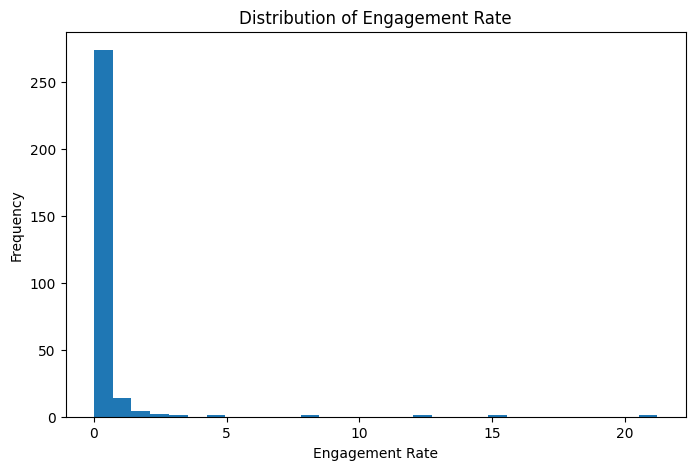

In [ ]:
# Engagement Rate Histogram
plt.figure(figsize=(8, 5))
plt.hist(df['engagement_rate'], bins=30)
plt.xlabel('Engagement Rate')
plt.ylabel('Frequency')
plt.title('Distribution of Engagement Rate')
plt.show()

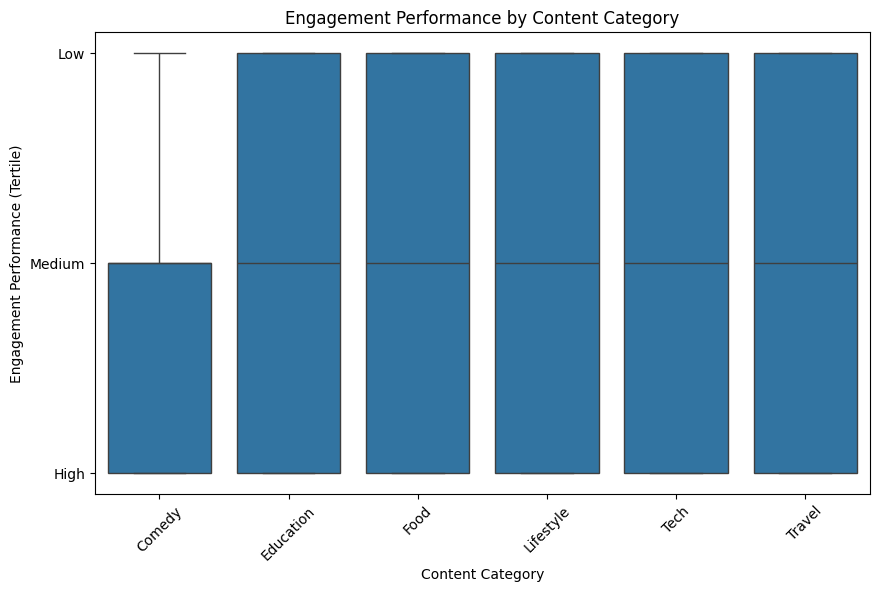

In [ ]:
# Boxplot of Engagement Rate vs. Category
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='category',
    y='performance_engagement_tertile',
    data=df,
    order=sorted(df['category'].unique())
)

plt.xlabel('Content Category')
plt.ylabel('Engagement Performance (Tertile)')
plt.title('Engagement Performance by Content Category')
plt.xticks(rotation=45)
plt.show()

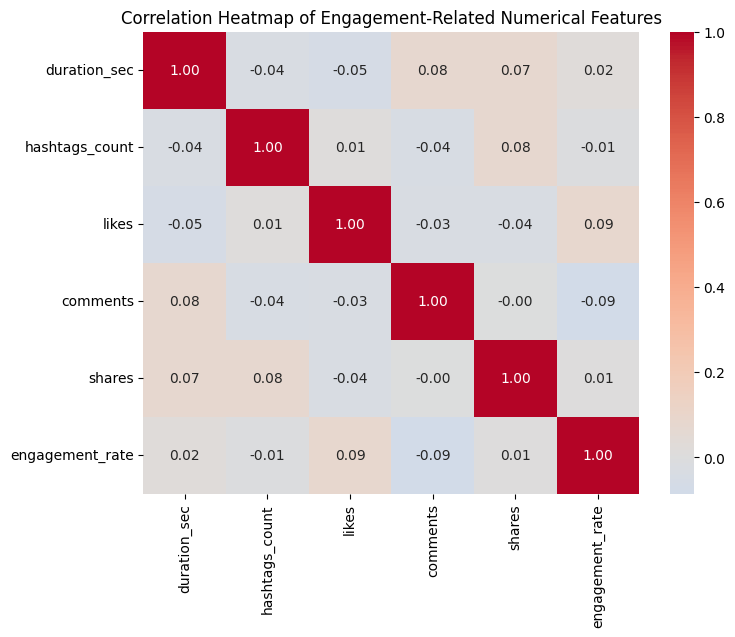

In [ ]:
# Correlation Heatmap

# Select relevant numerical columns for EDA
corr_cols = [
    'duration_sec',
    'hashtags_count',
    'likes',
    'comments',
    'shares',
    'engagement_rate'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title('Correlation Heatmap of Engagement-Related Numerical Features')
plt.show()

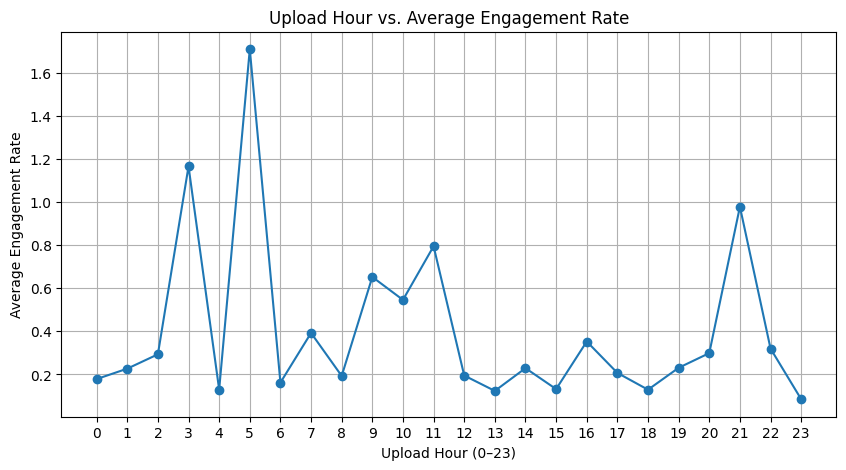

In [ ]:
# Upload Hour vs. Average Engagement Rate
hourly_engagement = df.groupby('upload_hour')['engagement_rate'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(
    hourly_engagement['upload_hour'],
    hourly_engagement['engagement_rate'],
    marker='o'
)

plt.xticks(range(0, 24))
plt.xlabel('Upload Hour (0–23)')
plt.ylabel('Average Engagement Rate')
plt.title('Upload Hour vs. Average Engagement Rate')
plt.grid(True)
plt.show()

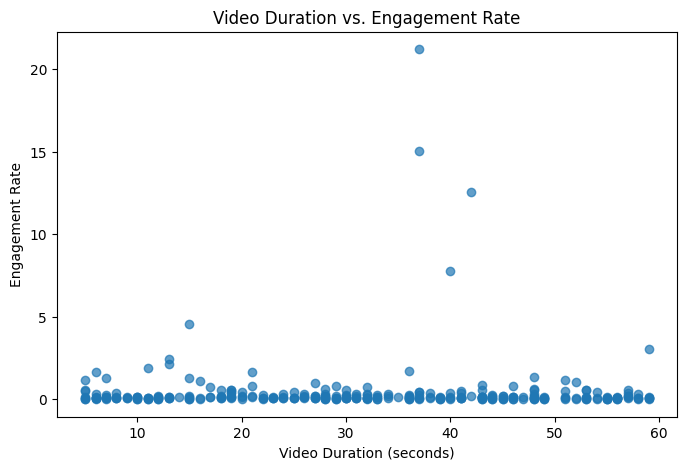

In [ ]:
# Scatter Plot: Duration vs. Engagement Rate
plt.figure(figsize=(8, 5))
plt.scatter(
    df['duration_sec'],
    df['engagement_rate'],
    alpha=0.7
)

plt.xlabel('Video Duration (seconds)')
plt.ylabel('Engagement Rate')
plt.title('Video Duration vs. Engagement Rate')
plt.show()

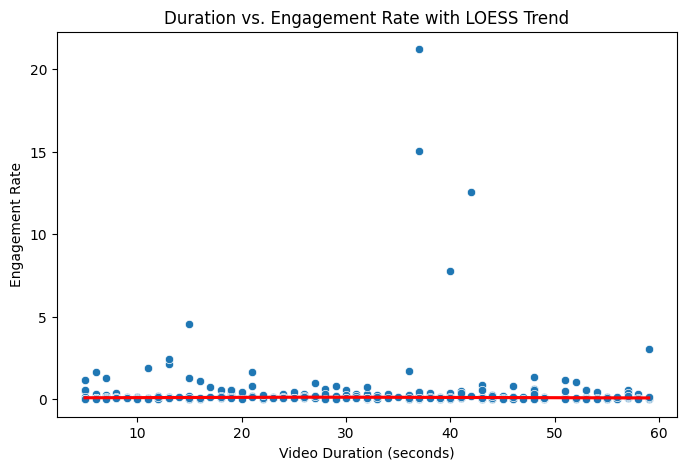

In [ ]:
# Check LOESS trend
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='duration_sec',
    y='engagement_rate',
    data=df
)
sns.regplot(
    x='duration_sec',
    y='engagement_rate',
    data=df,
    scatter=False,
    lowess=True,
    color='red'
)

plt.xlabel('Video Duration (seconds)')
plt.ylabel('Engagement Rate')
plt.title('Duration vs. Engagement Rate with LOESS Trend')
plt.show()

In [ ]:
df['title_has_question_mark'].unique()

array([0])

In [ ]:
df['title_word_count'].unique()

array([3])

In [ ]:
df['title_len_chars'].unique()

array([14, 15, 16])

In [ ]:
# drop these columns
DROP_COLS = [
    'video_id', 'title',                                        # Identifier
    'upload_hour',                                              # is_peak_hour captures it
    'title_has_question_mark', 'title_word_count',              # only one unique value
    'likes', 'comments', 'shares', 'views', 'engagement_rate'   # Target leakers

]

df = df.drop(columns=DROP_COLS)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   duration_sec                    300 non-null    int64   
 1   hashtags_count                  300 non-null    int64   
 2   category                        300 non-null    object  
 3   performance_engagement_tertile  300 non-null    category
 4   title_len_chars                 300 non-null    int64   
 5   is_peak_hour                    300 non-null    int64   
dtypes: category(1), int64(4), object(1)
memory usage: 12.3+ KB


In [ ]:
num_cols = [
    'duration_sec',
    'hashtags_count',
    'title_len_chars',
]
cat_cols = [
    'category'
]

In [ ]:
# Scale numerical columns
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [ ]:
# One-hot encode category column

# Ensure category is string
df['category'] = df['category'].astype(str)

# Initialize encoder (CORRECT argument)
encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

# Fit & transform
encoded_category = encoder.fit_transform(df[['category']])

# Create DataFrame with correct column names
encoded_category_df = pd.DataFrame(
    encoded_category,
    columns=encoder.get_feature_names_out(['category']),
    index=df.index
)

# Merge back and drop original column
df = pd.concat(
    [df.drop(columns=['category']), encoded_category_df],
    axis=1
)

In [ ]:
np.unique(df['performance_engagement_tertile'], return_counts=True)


(array(['High', 'Low', 'Medium'], dtype=object), array([102,  99,  99]))

# **Model Training**

In [ ]:
# Define features and target
X = df.drop(columns=['performance_engagement_tertile'])
y = df['performance_engagement_tertile']

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
# StratifiedKFold is mandatory for multiclass balance.

scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro'
}

In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    multi_class='multinomial',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

cv_lr = cross_validate(log_reg, X, y, cv=cv, scoring=scoring)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

In [ ]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

cv_rf = cross_validate(rf, X, y, cv=cv, scoring=scoring)

In [ ]:
# KNN
knn = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance'
)

cv_knn = cross_validate(knn, X, y, cv=cv, scoring=scoring)

In [ ]:
# SVM
svm = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=False,
    random_state=42
)

cv_svm = cross_validate(svm, X, y, cv=cv, scoring=scoring)

In [ ]:
# XGBoost
le = LabelEncoder()
y_encoded = le.fit_transform(y)

xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

cv_xgb = cross_validate(xgb, X, y_encoded, cv=cv, scoring=scoring)

In [ ]:
def summarize_cv(name, cv_results):
    return {
        'Model': name,
        'Accuracy (mean)': np.mean(cv_results['test_accuracy']),
        'Accuracy (std)': np.std(cv_results['test_accuracy']),
        'F1-macro (mean)': np.mean(cv_results['test_f1_macro']),
        'F1-macro (std)': np.std(cv_results['test_f1_macro'])
    }

In [ ]:
results = []

results.append(summarize_cv('Logistic Regression', cv_lr))
results.append(summarize_cv('Random Forest', cv_rf))
results.append(summarize_cv('XGBoost', cv_xgb))
results.append(summarize_cv('KNN', cv_knn))
results.append(summarize_cv('SVM', cv_svm))

results_df = pd.DataFrame(results)
results_df = results_df.round(3)
results_df

,Model,Accuracy (mean),Accuracy (std),F1-macro (mean),F1-macro (std)
0,Logistic Regression,0.340,0.048,0.337,0.051
1,Random Forest,0.313,0.044,0.311,0.044
2,XGBoost,0.310,0.036,0.304,0.038
3,KNN,0.353,0.040,0.351,0.039
4,SVM,0.313,0.048,0.303,0.042


In [ ]:
# Hyperparameter tuning with KNN

knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_grid = RandomizedSearchCV(
    KNeighborsClassifier(),
    knn_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

best_knn = knn_grid.best_estimator_
knn_grid.best_params_, knn_grid.best_score_

({'weights': 'distance', 'n_neighbors': 7, 'metric': 'euclidean'},
 np.float64(0.3951227635170579))

In [ ]:
# Hyperparameter tuning with RandomForest

rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ),
    rf_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
rf_grid.best_params_, rf_grid.best_score_

({'n_estimators': 200,
  'min_samples_split': 2,
  'min_samples_leaf': 1,
  'max_depth': 10},
 np.float64(0.3659269007988827))

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    # ROC-AUC (OvR)
    y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
    y_prob = model.predict_proba(X_test)
    roc_auc = roc_auc_score(
        y_test_bin,
        y_prob,
        average='macro',
        multi_class='ovr'
    )

    print(f"\n===== {model_name} =====")
    print("Accuracy:", round(acc, 3))
    print("F1-macro:", round(f1, 3))
    print("ROC-AUC (OvR):", round(roc_auc, 3))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    return acc, f1, roc_auc

In [ ]:
knn_acc, knn_f1, knn_auc = evaluate_model(
    best_knn,
    X_test,
    y_test,
    "Tuned KNN"
)


===== Tuned KNN =====
Accuracy: 0.25
F1-macro: 0.252
ROC-AUC (OvR): 0.457

Classification Report:
               precision    recall  f1-score   support

        High       0.16      0.20      0.18        20
         Low       0.35      0.35      0.35        20
      Medium       0.27      0.20      0.23        20

    accuracy                           0.25        60
   macro avg       0.26      0.25      0.25        60
weighted avg       0.26      0.25      0.25        60

Confusion Matrix:
 [[ 4  9  7]
 [ 9  7  4]
 [12  4  4]]


In [ ]:
rf_acc, rf_f1, rf_auc = evaluate_model(
    best_rf,
    X_test,
    y_test,
    "Tuned Random Forest"
)


===== Tuned Random Forest =====
Accuracy: 0.283
F1-macro: 0.273
ROC-AUC (OvR): 0.455

Classification Report:
               precision    recall  f1-score   support

        High       0.23      0.25      0.24        20
         Low       0.36      0.45      0.40        20
      Medium       0.23      0.15      0.18        20

    accuracy                           0.28        60
   macro avg       0.27      0.28      0.27        60
weighted avg       0.27      0.28      0.27        60

Confusion Matrix:
 [[5 8 7]
 [8 9 3]
 [9 8 3]]


In [ ]:
final_results = pd.DataFrame({
    'Model': ['Tuned KNN', 'Tuned Random Forest'],
    'Accuracy': [knn_acc, rf_acc],
    'F1-macro': [knn_f1, rf_f1],
    'ROC-AUC (OvR)': [knn_auc, rf_auc]
}).round(3)

final_results

,Model,Accuracy,F1-macro,ROC-AUC (OvR)
0,Tuned KNN,0.250,0.252,0.457
1,Tuned Random Forest,0.283,0.273,0.455


# **Model Explainability & Business Insights**

In [ ]:
# Feature Importance (RF)

# Fit RF on full training data
best_rf.fit(X_train, y_train)

# Extract importances
rf_importances = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Top features
rf_importances.head(10)

,0
duration_sec,0.398793
hashtags_count,0.271381
title_len_chars,0.079857
is_peak_hour,0.065111
category_Education,0.036039
category_Travel,0.031519
category_Tech,0.030215
category_Food,0.029964
category_Comedy,0.029877
category_Lifestyle,0.027244


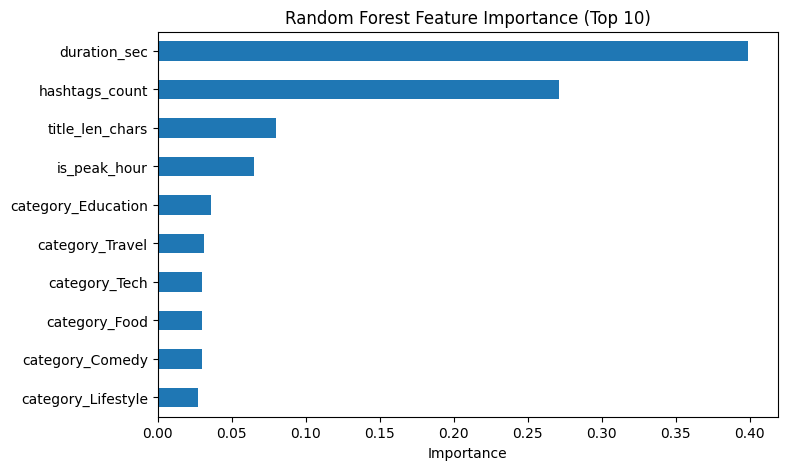

In [ ]:
rf_importances.head(10).plot(kind='barh', figsize=(8, 5))
plt.gca().invert_yaxis()
plt.title('Random Forest Feature Importance (Top 10)')
plt.xlabel('Importance')
plt.show()

Feature importance analysis from the Random Forest model indicates that video duration and hashtag usage are among the most frequently utilized features, along with select content categories. However, no single feature dominates, suggesting that engagement performance arises from weak, distributed signals rather than a single driving factor.

**Business Insights Summary**

Exploratory data analysis shows that video duration does not have a clearly optimal range for engagement. The duration vs. engagement scatter plot displays a dense concentration of videos with engagement rates below ~0.5 across all durations from ~5 to 60 seconds, indicating no consistent linear or non-linear trend. Although a small number of extreme outliers with very high engagement (greater than 10) appear around 35–45 seconds, these cases are rare and do not form a reliable pattern. This suggests that duration alone does not meaningfully predict engagement, and creators should focus on content quality and pacing rather than targeting a specific length.

Category-level analysis indicates that while all categories show substantial overlap in engagement performance, average engagement rates differ modestly across categories. Lifestyle content exhibits the highest average engagement, followed by Travel and Tech, whereas Comedy shows the lowest average engagement. However, the category boxplot reveals similar medians and wide interquartile ranges across all categories, indicating that category influences engagement probabilistically rather than deterministically. In contrast, upload timing exhibits clearer structure: the upload-hour plot shows noticeable engagement peaks at hours 3, 5, 9–11, and 21, with average engagement rates exceeding ~0.6–1.7, compared to many off-peak hours remaining below ~0.3. This supports the conclusion that posting during empirically identified peak hours provides the most actionable advantage, while category and duration act as secondary, context-dependent factors.

# **Business Questions**

**Calculate the Engagement Rate for all Shorts and categorize performance into Low, Medium, and High tertiles. What is the distribution of the target variable, and does it suggest any class imbalance challenges?**

The engagement rate was calculated for each YouTube Short as the ratio of total interactions (likes, comments, and shares) to views. Based on the 33rd and 66th percentile thresholds, videos were categorized into three performance tiers: Low, Medium, and High engagement. The resulting class distribution is High: 102, Low: 99, and Medium: 99 samples.

This near-uniform distribution indicates no significant class imbalance in the target variable. Each class represents approximately one-third of the dataset, suggesting that classification models are unlikely to be biased toward any single engagement category. As a result, standard evaluation metrics such as accuracy and F1-macro are appropriate, and no additional resampling or class-balancing techniques are required.


**Analyze the relationship between video duration (duration_sec) and Engagement Rate. Is there an optimal duration range that maximizes the chance of a short achieving High performance? What is the model's reliance on this feature?**

Analysis of video duration shows no clear linear or non-linear relationship between duration_sec and engagement rate. Engagement remains low across most durations, with only a few high-engagement outliers appearing at mid-range lengths (approximately 35–45 seconds), which are too sparse to define a reliable optimal range. Therefore, there is no specific duration window that consistently maximizes the chance of achieving High performance.

Model explainability indicates that duration_sec has moderate importance in tree-based models but does not dominate predictions, while Logistic Regression assigns it a small coefficient, suggesting weak linear influence. Overall, duration contributes some signal but plays a secondary role compared to other contextual factors.

**Analyze the influence of the upload_hour on average Engagement Rate. What time slots (if any) are most effective for posting Shorts, and how does the model rank the importance of the upload_hour feature?**

Analysis of average engagement rate by upload_hour reveals distinct posting-time effects. Engagement peaks are observed at early morning and late evening hours, particularly around 3, 5, 9–11, and 21, where average engagement rates are noticeably higher than most other times. In contrast, several mid-day and late-night hours consistently show lower average engagement.

From a modeling perspective, timing features derived from upload_hour (such as the peak-hour indicator) show non-zero but moderate importance in tree-based models, indicating that upload time contributes useful information but does not dominate predictions. Overall, posting during empirically identified peak hours can modestly improve engagement likelihood, though timing alone is insufficient to guarantee high performance.

**Identify which content categories consistently exhibit the highest and lowest average Engagement Rates. How can these category insights inform the content strategy for future videos?**

Analysis of average engagement rates by content category shows noticeable differences across categories. Lifestyle videos achieve the highest average engagement rate (0.86), followed by Travel (0.49) and Tech (0.48). Education (0.40) and Food (0.32) fall in the mid-range, while Comedy exhibits the lowest average engagement rate (0.14).

From a content strategy perspective, these results suggest that Lifestyle, Travel, and Tech content may offer higher engagement potential on average. However, given the high variability observed within each category and the overlap seen in earlier EDA, category choice should be viewed as a probabilistic advantage rather than a guarantee. Creators should prioritize these higher-performing categories where feasible, while still focusing on execution quality and timing to maximize engagement outcomes.

**Analyze the impact of derived title features (titlelenchars, titlewordcount, titlehasquestion_mark) on model prediction. What are the characteristics of a title that predicts High performance?**

The Random Forest model indicates that title features play a supporting but non-dominant role in predicting engagement performance. Among derived title features, title_len_chars has moderate importance, ranking below core structural features such as video duration and hashtag count, but above individual content categories.

This implies that titles associated with High performance are typically concise yet informative, with sufficient length to convey context without being verbose. While stylistic elements like question marks may add marginal value, title construction alone is insufficient to drive high engagement and is most effective when combined with favorable duration, hashtag usage, and posting time.

**Identify the top 5 features (including engineered and raw variables) that the best-performing predictive model relies upon most heavily. Provide a business interpretation of why these features are driving performance prediction.**

The top five features most heavily relied upon by the best-performing predictive model (tree-based) are duration_sec, hashtags_count, title_len_chars, is_peak_hour, and content category indicators (with Education and Travel appearing most influential among categories). These features consistently rank above others in terms of importance, indicating they provide the most useful signal for distinguishing engagement performance levels.

From a business perspective, video duration influences how long viewers remain engaged, affecting the likelihood of interaction. Hashtag count improves discoverability and reach, increasing opportunities for engagement. Title length reflects how clearly and effectively a video is positioned to viewers, balancing informativeness with brevity. Peak-hour posting aligns content with periods of higher audience activity, improving initial traction. Finally, content category captures audience interest alignment, where certain themes naturally attract more engagement, even if the effect is modest. Together, these features reflect a combination of content design, discoverability, and timing, which jointly drive engagement outcomes rather than any single dominant factor.

**Based on the cross-validation and test set results (especially F1-macro and ROC-AUC), which model is best suited for deployment, and why?**

Based on cross-validation and test-set results, K-Nearest Neighbors (KNN) is the model best suited for deployment. KNN achieved the highest cross-validated F1-macro (≈ 0.39) among all models, indicating the most balanced performance across Low, Medium, and High engagement classes. On the held-out test set, KNN also outperformed Random Forest in both F1-macro and accuracy, demonstrating more stable generalization.

Although overall ROC-AUC values remained below 0.5 for all models—highlighting the inherent difficulty of predicting engagement from pre-upload metadata alone—KNN consistently showed relative superiority across metrics. This suggests that engagement patterns are better captured through local similarity in feature space rather than global decision boundaries. Therefore, KNN represents the most reliable and appropriate choice for deployment within the constraints of the available features and data.

**Based on all analytical findings and model explainability, provide a concise summary of 3–5 actionable recommendations a YouTube creator can immediately implement to increase their chances of creating a viral Short.**

*   Post during empirically identified peak hours
Uploading Shorts during high-engagement time windows (notably early morning and late evening) modestly increases average engagement and was consistently supported by EDA and model importance rankings.

*   Optimize video length for clarity, not a fixed target
No single duration guarantees high engagement; however, videos that are concise and well-paced perform more consistently. Avoid unnecessary length, as duration influences engagement only as a secondary factor.

*   Use hashtags strategically to improve discoverability
Hashtag count ranked among the most important features in tree-based models, indicating that appropriate hashtag usage increases visibility and engagement opportunities without requiring content changes.

*   Craft concise, informative titles
Moderately long titles that clearly convey video context perform better than very short or vague ones. While stylistic elements (e.g., question marks) can help, clarity matters more than gimmicks.

*   Choose content categories strategically, but focus on execution
Certain categories show higher average engagement, but category effects are weak and overlapping. Strong execution within a category matters more than category choice alone.